<a href="https://colab.research.google.com/github/pranathiperii/Spatial-GNN/blob/main/spatial_transcriptomic_GNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install -q scanpy squidpy

  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.8/87.8 kB 7.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 69.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 193.9/193.9 kB 22.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 176.6/176.6 kB 21.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.9/61.9 kB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.2/23.2 MB 17.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.6/51.6 kB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 192.3/192.3 kB 21.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.7/44.7 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 295.7/295.7 kB 30.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 

In [2]:
import squidpy as sq
import scanpy as sc

adata = sq.datasets.visium_hne_adata()
print(adata)

INFO     Downloading visium_hne_adata.h5ad from                                                                    
         https://exampledata.scverse.org/squidpy/figshare/visium_hne_adata.h5ad                                    


  0%|                                               | 0.00/329M [00:00<?, ?B/s]

AnnData object with n_obs × n_vars = 2688 × 18078
    obs: 'in_tissue', 'array_row', 'array_col', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'n_counts', 'leiden', 'cluster'
    var: 'gene_ids', 'feature_types', 'genome', 'mt', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm'
    uns: 'cluster_colors', 'hvg', 'leiden', 'leiden_colors', 'neighbors', 'pca', 'rank_genes_groups', 'spatial', 'umap'
    obsm: 'X_pca', 'X_umap', 'spatial'
    varm: 'PCs'
    obsp: 'connectivities', 'distances'


/tmp/ipykernel_1232/1573821980.py:3: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(adata, img_key='hires', spot_size=0.08, color='cluster')


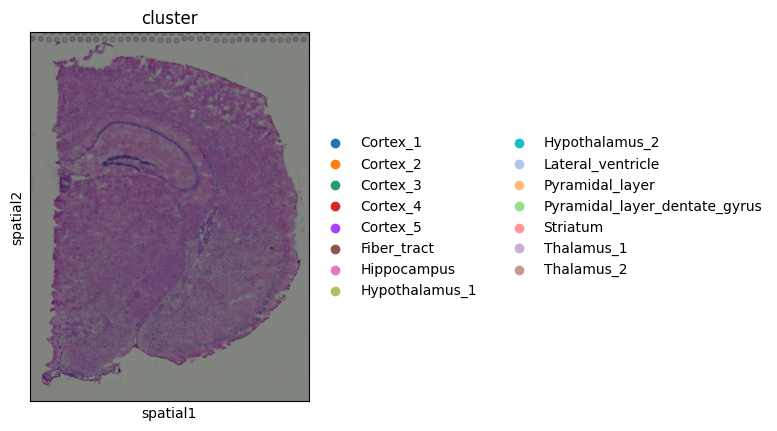

In [3]:
import matplotlib.pyplot as plt

sc.pl.spatial(adata, img_key='hires', spot_size=0.08, color='cluster')

In [4]:
import numpy as np

print(type(adata.X))
print(adata.X.shape)
print(adata.X[0:5, 0:5].toarray())

<class 'scipy.sparse._csr.csr_matrix'>
(2688, 18078)
[[0.         0.         0.87893134 0.87893134 1.3393729 ]
 [0.         0.         1.0922161  1.0922161  1.0922161 ]
 [0.         0.         0.         0.         0.9803591 ]
 [0.         0.         0.         0.         0.        ]
 [0.         0.         0.99697125 0.         0.6179012 ]]


In [5]:
print(adata.obsm['spatial'][:5])

[[8230 7237]
 [4170 1611]
 [2519 8315]
 [7679 2927]
 [3138 6280]]


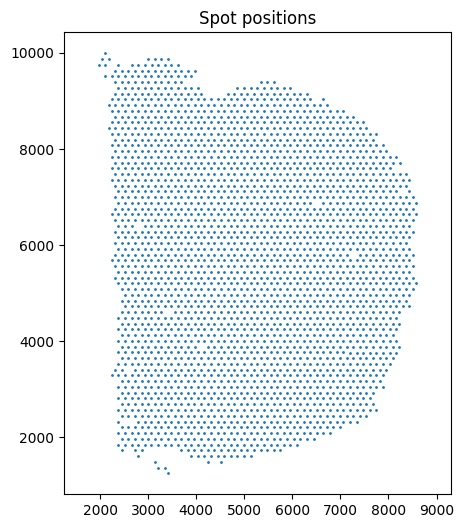

In [6]:
import matplotlib.pyplot as plt

coords = adata.obsm['spatial']
plt.figure(figsize=(5,6))
plt.scatter(coords[:,0], coords[:,1], s=1)
plt.title('Spot positions')
plt.axis('equal')
plt.show()

/tmp/ipykernel_1232/150922409.py:1: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(adata, img_key='hires', spot_size=0.08,


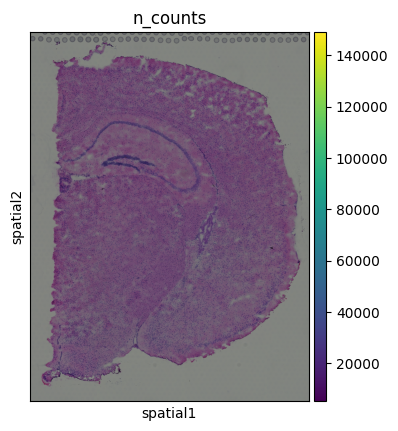

In [7]:
sc.pl.spatial(adata, img_key='hires', spot_size=0.08,
              color='n_counts', cmap='viridis')

In [8]:
print(adata.var['highly_variable'].sum())
print(adata.var['highly_variable'].value_counts())

4000
highly_variable
False    14078
True      4000
Name: count, dtype: int64


In [9]:
sc.pp.highly_variable_genes(adata, n_top_genes= 200)
adata_hvg = adata[:, adata.var['highly_variable']].copy()
print(adata_hvg)

AnnData object with n_obs × n_vars = 2688 × 200
    obs: 'in_tissue', 'array_row', 'array_col', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'n_counts', 'leiden', 'cluster'
    var: 'gene_ids', 'feature_types', 'genome', 'mt', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'dispersions', 'dispersions_norm'
    uns: 'cluster_colors', 'hvg', 'leiden', 'leiden_colors', 'neighbors', 'pca', 'rank_genes_groups', 'spatial', 'umap'
    obsm: 'X_pca', 'X_umap', 'spatial'
    varm: 'PCs'
    obsp: 'connectivities', 'distances'


In [10]:
import numpy as np

if hasattr(adata_hvg.X, 'toarray'):
    Y = adata_hvg.X.toarray()
else:
    Y = np.array(adata_hvg.X)

print(Y.shape)
print(Y[0:3, 0:5])

(2688, 200)
[[0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]]


In [11]:
print("Max value in Y:", Y.max())
print("Mean value in Y:", Y.mean())
print("How many non-zero values:", (Y != 0).sum())
print("Total values:", Y.size)


Max value in Y: 7.879248
Mean value in Y: 0.3203366
How many non-zero values: 136985
Total values: 537600


In [12]:
library_id = list(adata.uns['spatial'].keys())[0]
print(library_id)

img = adata.uns['spatial'][library_id]['images']['hires']
print(img.shape)
print(img.max())


V1_Adult_Mouse_Brain
(2000, 1921, 3)
0.7372549


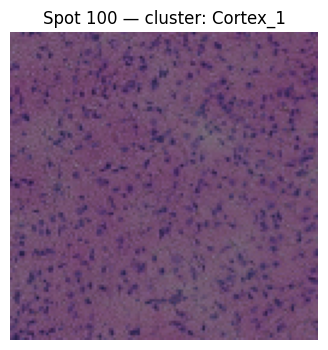

In [13]:
import matplotlib.pyplot as plt
import numpy as np

# Get coordinates and scale factor
scale = adata.uns['spatial'][library_id]['scalefactors']['tissue_hires_scalef']
coords = adata.obsm['spatial'] * scale

# Look at spot 100 - pick any number you like
spot_idx = 100
cx, cy = int(coords[spot_idx, 0]), int(coords[spot_idx, 1])

# Crop a 128x128 patch around it
PATCH = 64  # 64 pixels in each direction from center
patch = img[cy-PATCH:cy+PATCH, cx-PATCH:cx+PATCH]

plt.figure(figsize=(4,4))
plt.imshow(patch)
plt.title(f'Spot {spot_idx} — cluster: {adata.obs["cluster"].iloc[spot_idx]}')
plt.axis('off')
plt.show()

In [14]:
# Find a hippocampus spot
hip_spots = adata.obs[adata.obs['cluster'] == 'Hippocampus'].index
print(hip_spots[:5])

# Get the integer position of the first one
hip_idx = adata.obs.index.get_loc(hip_spots[0])
print(hip_idx)

Index(['AAAGGGATGTAGCAAG-1', 'AACCCAGAGACGGAGA-1', 'AACCGAGCTTGGTCAT-1',
       'AACTGGGTCCCGACGT-1', 'AACTTGCGTTCTCGCG-1'],
      dtype='object')
17


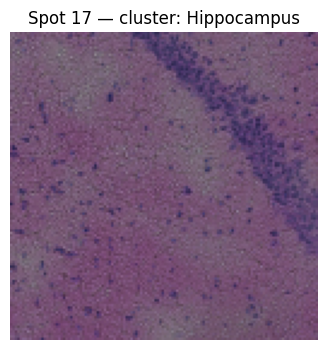

In [15]:
spot_idx = 17
cx, cy = int(coords[spot_idx, 0]), int(coords[spot_idx, 1])
patch = img[cy-PATCH:cy+PATCH, cx-PATCH:cx+PATCH]

plt.figure(figsize=(4,4))
plt.imshow(patch)
plt.title(f'Spot {spot_idx} — cluster: {adata.obs["cluster"].iloc[spot_idx]}')
plt.axis('off')
plt.show()

In [20]:
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(DEVICE)

cuda


In [21]:
import torchvision.models as models
import torchvision.transforms as T
from PIL import Image
import torch
import torch.nn as nn

resnet = models.resnet50(weights='IMAGENET1K_V1')
resnet.fc = nn.Identity()
resnet = resnet.to(DEVICE)
resnet.eval()

print(resnet.fc)  # should print Identity()

Identity()


In [18]:
import torchvision.transforms as T

In [22]:
import torchvision.models as models
import torchvision.transforms as T
from PIL import Image

In [23]:
transform = T.Compose([
    T.Resize((224, 224)),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406],
                std =[0.229, 0.224, 0.225])
])

In [25]:
features = []  # empty list to collect results

for i in range(len(coords)):
    cx, cy = int(coords[i, 0]), int(coords[i, 1])


    patch = img[cy-PATCH:cy+PATCH, cx-PATCH:cx+PATCH]

    features.append(patch)  # save it

print(len(features))
print(features[0].shape)

2688
(128, 128, 3)


In [26]:
features = []

with torch.no_grad():  # don't compute gradients - we're not training ResNet
    for i in range(len(coords)):
        cx, cy = int(coords[i, 0]), int(coords[i, 1])

        # clamp to image boundaries (edge spots might go out of bounds)
        x0, x1 = max(0, cx-PATCH), min(img.shape[1], cx+PATCH)
        y0, y1 = max(0, cy-PATCH), min(img.shape[0], cy+PATCH)

        patch = img[y0:y1, x0:x1]

        # convert to PIL
        patch_pil = Image.fromarray(
            (patch * 255).astype(np.uint8)
        )

        # apply transform and add batch dimension
        tensor = transform(patch_pil).unsqueeze(0).to(DEVICE)

        feat = resnet(tensor).squeeze().cpu().numpy()

        features.append(feat)

        if (i+1) % 500 == 0:
            print(f"{i+1}/2688 done")

X = np.array(features)
print(f"X shape: {X.shape}")

500/2688 done
1000/2688 done
1500/2688 done
2000/2688 done
2500/2688 done
X shape: (2688, 2048)


In [27]:
print("X — one spot's morphology features:")
print(X[17])   # hippocampus spot we looked at earlier

X — one spot's morphology features:
[0.02609062 1.085189   0.022744   ... 0.2557509  0.         0.42214966]


In [28]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(X_scaled.mean().round(3))  # should be ~0
print(X_scaled.std().round(3))   # should be ~1

0.0
1.0


In [29]:
print(X_scaled.std(axis=0).mean())  # std per feature, then average

0.9999999


In [30]:
from sklearn.neighbors import NearestNeighbors

K = 6  # hexagonal grid - 6 neighbors

nbrs = NearestNeighbors(n_neighbors=7, metric='euclidean')
nbrs.fit(coords)  # what do we fit on? spatial coordinates
_, indices = nbrs.kneighbors(coords)

print(indices.shape)
print("Neighbors of spot 17:", indices[17])

(2688, 7)
Neighbors of spot 17: [  17 2170 2148  257 2682  581 1823]


In [31]:
print(adata.obs['cluster'].iloc[17])
print(adata.obs['cluster'].iloc[[2170, 2148, 257, 2682, 581, 1823]])

Hippocampus
TCAAACAACCGCGTCG-1    Hippocampus
TATGCTCCCTACTTAC-1       Cortex_5
ACGATCATACATAGAG-1    Hippocampus
TTGTTCAGTGTGCTAC-1    Hippocampus
ATCGACTCTTTCCGTT-1    Hippocampus
GTAAGCGGGCAGTCAG-1    Hippocampus
Name: cluster, dtype: category
Categories (15, object): ['Cortex_1', 'Cortex_2', 'Cortex_3', 'Cortex_4', ...,
                          'Pyramidal_layer_dentate_gyrus', 'Striatum', 'Thalamus_1', 'Thalamus_2']


In [32]:
src, dst = [], []

for i in range(len(indices)):
    for j in indices[i, 1:]:  # skip index 0 (self)
        src.append(i)
        dst.append(j)

# make bidirectional
edge_index = torch.tensor([src + dst, dst + src], dtype=torch.long)
print(edge_index.shape)

torch.Size([2, 32256])


In [34]:
!pip install -q torch_geometric

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 42.4 MB/s eta 0:00:00


In [35]:
from torch_geometric.data import Data

graph = Data(
    x          = torch.tensor(X_scaled, dtype=torch.float32),
    edge_index = edge_index,
    y          = torch.tensor(Y, dtype=torch.float32)
)

print(graph)

Data(x=[2688, 2048], edge_index=[2, 32256], y=[2688, 200])


In [36]:
from sklearn.model_selection import train_test_split
import numpy as np

n = graph.num_nodes
idx = np.arange(n)

train_idx, temp_idx = train_test_split(idx, test_size=0.30, random_state=42)
val_idx, test_idx   = train_test_split(temp_idx, test_size= 0.50, random_state=42)

print(len(train_idx), len(val_idx), len(test_idx))

1881 403 404


In [37]:
def make_mask(idx_list, n):
    mask = torch.zeros(n, dtype=torch.bool)
    mask[idx_list] = True
    return mask

graph.train_mask = make_mask(train_idx, n)
graph.val_mask   = make_mask(val_idx, n)
graph.test_mask  = make_mask(test_idx, n)

print(graph)

Data(x=[2688, 2048], edge_index=[2, 32256], y=[2688, 200], train_mask=[2688], val_mask=[2688], test_mask=[2688])


In [38]:
print(graph.train_mask[:20])  # first 20 values
print(f"True values: {graph.train_mask.sum().item()}")  # should be 1881

tensor([ True,  True,  True,  True,  True,  True,  True,  True,  True,  True,
         True,  True,  True,  True,  True,  True,  True,  True, False,  True])
True values: 1881


In [39]:
import torch.nn.functional as F
from torch_geometric.nn import SAGEConv

class SpatialGNN(nn.Module):
    def __init__(self, in_dim, hidden_dim, out_dim):
        super().__init__()
        self.conv1 = SAGEConv(in_dim, hidden_dim)
        self.conv2 = SAGEConv(hidden_dim, hidden_dim)
        self.head  = nn.Linear(hidden_dim, out_dim)

    def forward(self, x, edge_index):
        x = F.relu(self.conv1(x, edge_index))
        x = F.relu(self.conv2(x, edge_index))
        return self.head(x)

gnn = SpatialGNN(in_dim=2048, hidden_dim=256, out_dim=200).to(DEVICE)
print(gnn)

SpatialGNN(
  (conv1): SAGEConv(2048, 256, aggr=mean)
  (conv2): SAGEConv(256, 256, aggr=mean)
  (head): Linear(in_features=256, out_features=200, bias=True)
)


In [40]:
optimizer = torch.optim.Adam(gnn.parameters(), lr=0.001)
criterion = nn.MSELoss()

x          = graph.x.to(DEVICE)
edge_index = graph.edge_index.to(DEVICE)
y          = graph.y.to(DEVICE)
train_mask = graph.train_mask.to(DEVICE)
val_mask   = graph.val_mask.to(DEVICE)

for epoch in range(1, 51):
    gnn.train()
    optimizer.zero_grad()
    out  = gnn(x, edge_index)           # forward pass - what two things does gnn need?
    loss = criterion(out[train_mask], y[train_mask])
    loss.backward()
    optimizer.step()

    if epoch % 10 == 0:
        print(f"Epoch {epoch} | Loss: {loss.item():.4f}")

Epoch 10 | Loss: 0.2613
Epoch 20 | Loss: 0.2130
Epoch 30 | Loss: 0.1838
Epoch 40 | Loss: 0.1646
Epoch 50 | Loss: 0.1523


In [41]:
from scipy.stats import pearsonr

gnn.eval()
with torch.no_grad():
    preds = gnn(x, edge_index).cpu().numpy()

y_true    = graph.y.numpy()
test_mask = graph.test_mask.numpy()

correlations = []
for g in range(200):
    r, _ = pearsonr(y_true[test_mask, g], preds[test_mask, g])
    correlations.append(r)

correlations = np.array(correlations)
print(f"Mean Pearson R:   {np.nanmean(correlations):.3f}")
print(f"Median Pearson R: {np.nanmedian(correlations):.3f}")
print(f"Genes with R>0.3: {(correlations > 0.3).sum()}")
print(f"Genes with R>0.5: {(correlations > 0.5).sum()}")

/tmp/ipykernel_1232/3559916303.py:12: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r, _ = pearsonr(y_true[test_mask, g], preds[test_mask, g])


Mean Pearson R:   0.496
Median Pearson R: 0.524
Genes with R>0.3: 161
Genes with R>0.5: 109


Best predicted gene: Fndc3c1 (R=nan)


/tmp/ipykernel_1232/1782959390.py:9: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(adata_hvg, color=['true_expr', 'pred_expr'],


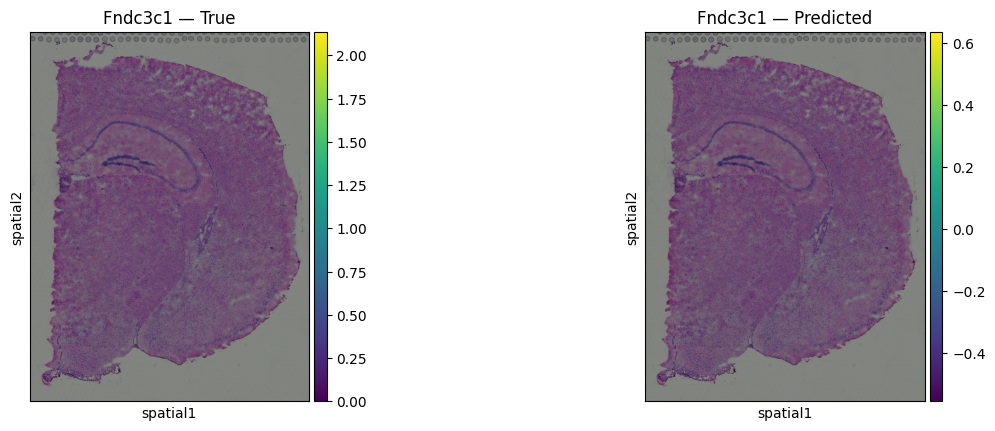

In [42]:
# find the best predicted gene
best_gene_idx  = np.argmax(correlations)
best_gene_name = adata_hvg.var_names[best_gene_idx]
print(f"Best predicted gene: {best_gene_name} (R={correlations[best_gene_idx]:.3f})")

adata_hvg.obs['true_expr'] = y_true[:, best_gene_idx]
adata_hvg.obs['pred_expr'] = preds[:, best_gene_idx]

sc.pl.spatial(adata_hvg, color=['true_expr', 'pred_expr'],
              img_key='hires', spot_size=0.08,
              title=[f'{best_gene_name} — True', f'{best_gene_name} — Predicted'])

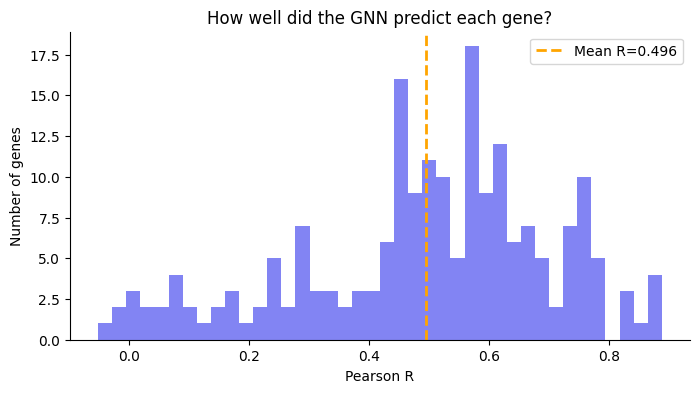

In [43]:
plt.figure(figsize=(8, 4))
plt.hist(correlations, bins=40, color='#6366f1', alpha=0.8)
plt.axvline(np.nanmean(correlations), color='orange',
            linestyle='--', linewidth=2, label=f'Mean R={np.nanmean(correlations):.3f}')
plt.xlabel('Pearson R')
plt.ylabel('Number of genes')
plt.title('How well did the GNN predict each gene?')
plt.legend()
plt.spines = plt.gca()
plt.spines.spines[['top','right']].set_visible(False)
plt.show()